In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist         # библиотека базы выборок Mnist
from tensorflow import keras
from tensorflow.keras.layers import Dense, Flatten

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [ ]:
# стандартизация входных данных
x_train = x_train / 255
x_test = x_test / 255

In [ ]:
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

In [ ]:
size_val = 10000
x_val_split = x_train[:size_val]
y_val_split = y_train_cat[:size_val]

x_train_split = x_train[size_val:]
y_train_split = y_train_cat[size_val:]

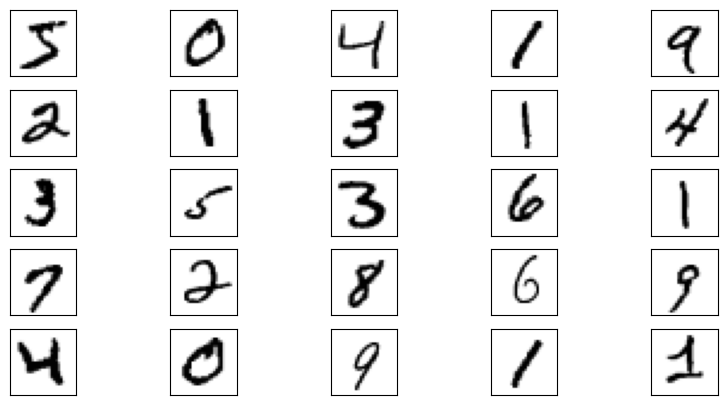

In [ ]:
# отображение первых 25 изображений из обучающей выборки
plt.figure(figsize=(10,5))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[i], cmap=plt.cm.binary)

plt.show()

In [ ]:
model = keras.Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

print(model.summary())      # вывод структуры НС в консоль

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
myAdam = keras.optimizers.Adam(learning_rate=0.1)

mySGD = keras.optimizers.SGD(learning_rate=0.1, momentum=0.0, nesterov=True)

model.compile(optimizer=mySGD,
             loss='categorical_crossentropy',
             metrics=['accuracy'])

In [ ]:
from sklearn.model_selection import train_test_split

x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(x_train, y_train_cat, test_size=0.2)
model.fit(x_train_split, y_train_split, batch_size=32, epochs=5, validation_data=(x_val_split, y_val_split))

model.fit(x_train_split, y_train_split, batch_size=32, epochs=5, validation_data=(x_val_split, y_val_split))

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9060 - loss: 0.3272 - val_accuracy: 0.9427 - val_loss: 0.2003
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9530 - loss: 0.1615 - val_accuracy: 0.9594 - val_loss: 0.1436
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9662 - loss: 0.1144 - val_accuracy: 0.9634 - val_loss: 0.1280
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9741 - loss: 0.0898 - val_accuracy: 0.9693 - val_loss: 0.1065
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9792 - loss: 0.0729 - val_accuracy: 0.9697 - val_loss: 0.1028
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9824 - loss: 0.0618 - val_accuracy: 0.9694 - val_loss: 0.1011
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9849 - loss: 0.0527 - val_accuracy: 0.9736 - val_loss: 0.0896
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9868 - loss: 0.0451 - val_ac

In [ ]:
model.evaluate(x_test, y_test_cat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9745 - loss: 0.0810


[0.08102472871541977, 0.9745000004768372]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
[[0.    0.    0.997 0.003 0.    0.    0.    0.    0.    0.   ]]
2


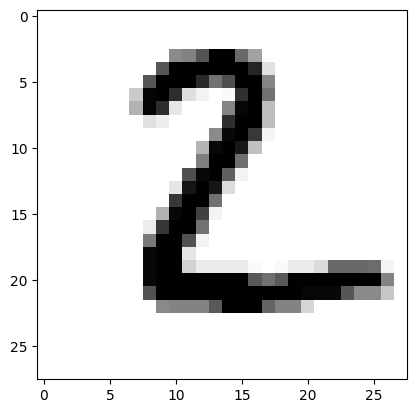

In [ ]:
n = 1
x = np.expand_dims(x_test[n], axis=0)
res = model.predict(x)
print(np.round(res, 3))
print( np.argmax(res) )

plt.imshow(x_test[n], cmap=plt.cm.binary)
plt.show()

In [ ]:
# Распознавание всей тестовой выборки
pred = model.predict(x_test)
pred = np.argmax(pred, axis=1)

print(pred.shape)

print(pred[:20])
print(y_test[:20])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
(10000,)
[7 2 1 0 4 1 4 9 6 9 0 6 9 0 1 5 9 7 3 4]
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


In [ ]:
# Выделение неверных вариантов
mask = pred == y_test
print(mask[:10])

x_false = x_test[~mask]
y_false = pred[~mask]

print(x_false.shape)

[ True  True  True  True  True  True  True  True False  True]
(255, 28, 28)


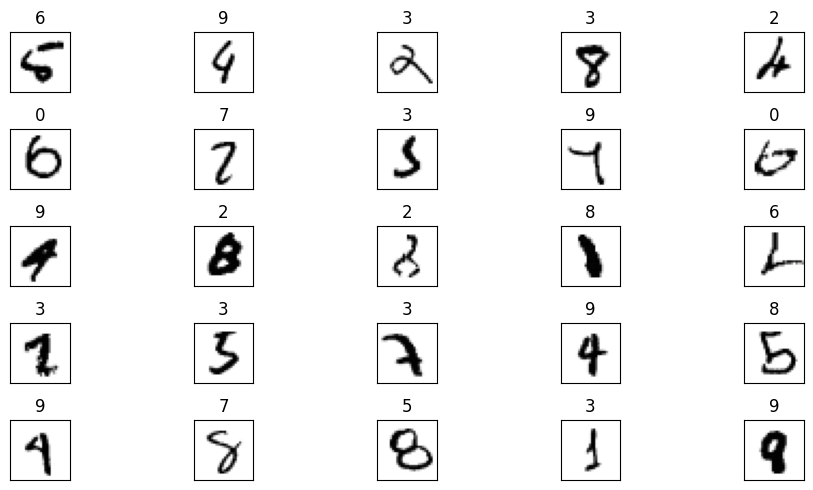

In [ ]:
# Вывод первых 25 неверных результатов
plt.figure(figsize=(10,5))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_false[i], cmap=plt.cm.binary)
    plt.title(y_false[i])

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, precision_score, recall_score

# Hər rəqəm (0-9) üçün ətraflı hesabat
print(classification_report(y_test, pred))

# Ümumi (bütün rəqəmlər üzrə orta) precision və recall
precision = precision_score(y_test, pred, average='macro')
recall = recall_score(y_test, pred, average='macro')
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.94      0.99      0.96      1010
           4       0.98      0.97      0.98       982
           5       0.98      0.96      0.97       892
           6       0.98      0.97      0.98       958
           7       0.98      0.97      0.97      1028
           8       0.98      0.95      0.97       974
           9       0.96      0.97      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000

Precision: 0.9747
Recall: 0.9741


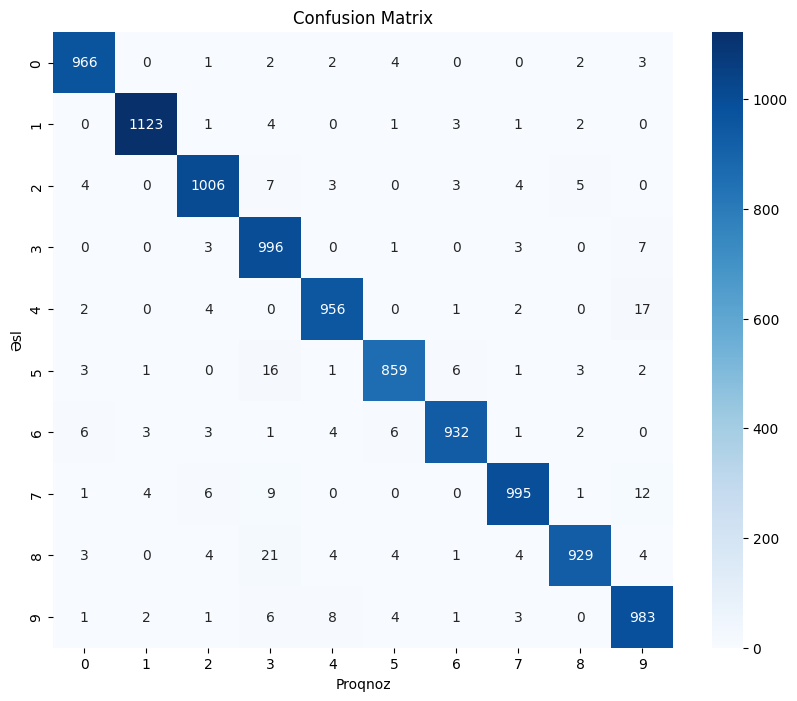

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Proqnoz')
plt.ylabel('Əsl')
plt.title('Confusion Matrix')
plt.show()